Auger (limit)
Auger
HAWC+IceCube
HAWC
K-Grande (not sig.) (x1.3)
K-Grande (limit) (x1.3)
Baksan
EAS-TOP (x1.4)
MACRO
Super-K (x1.2)
Milagro (x1.2)
ARGO-YBJ (x1.2)
Tibet-AS$\gamma$ (x1.2)
LHAASO (x1.2)
IceTop (2013) (x1.7)
IceTop (limit)
IceTop (this work)
IceCube (2025)
IceCube (limit) (2025)


/tmp/ipykernel_9889/526321860.py:102: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "*" (-> marker='*'). The keyword argument will take precedence.
  ax1.errorbar(dE, alpha, yerr=dalpha,
/tmp/ipykernel_9889/526321860.py:107: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "*" (-> marker='*'). The keyword argument will take precedence.
  ax2.errorbar(dE,A,yerr=[dAlo,dAhi],fmt="*",marker=detector.shape,
/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


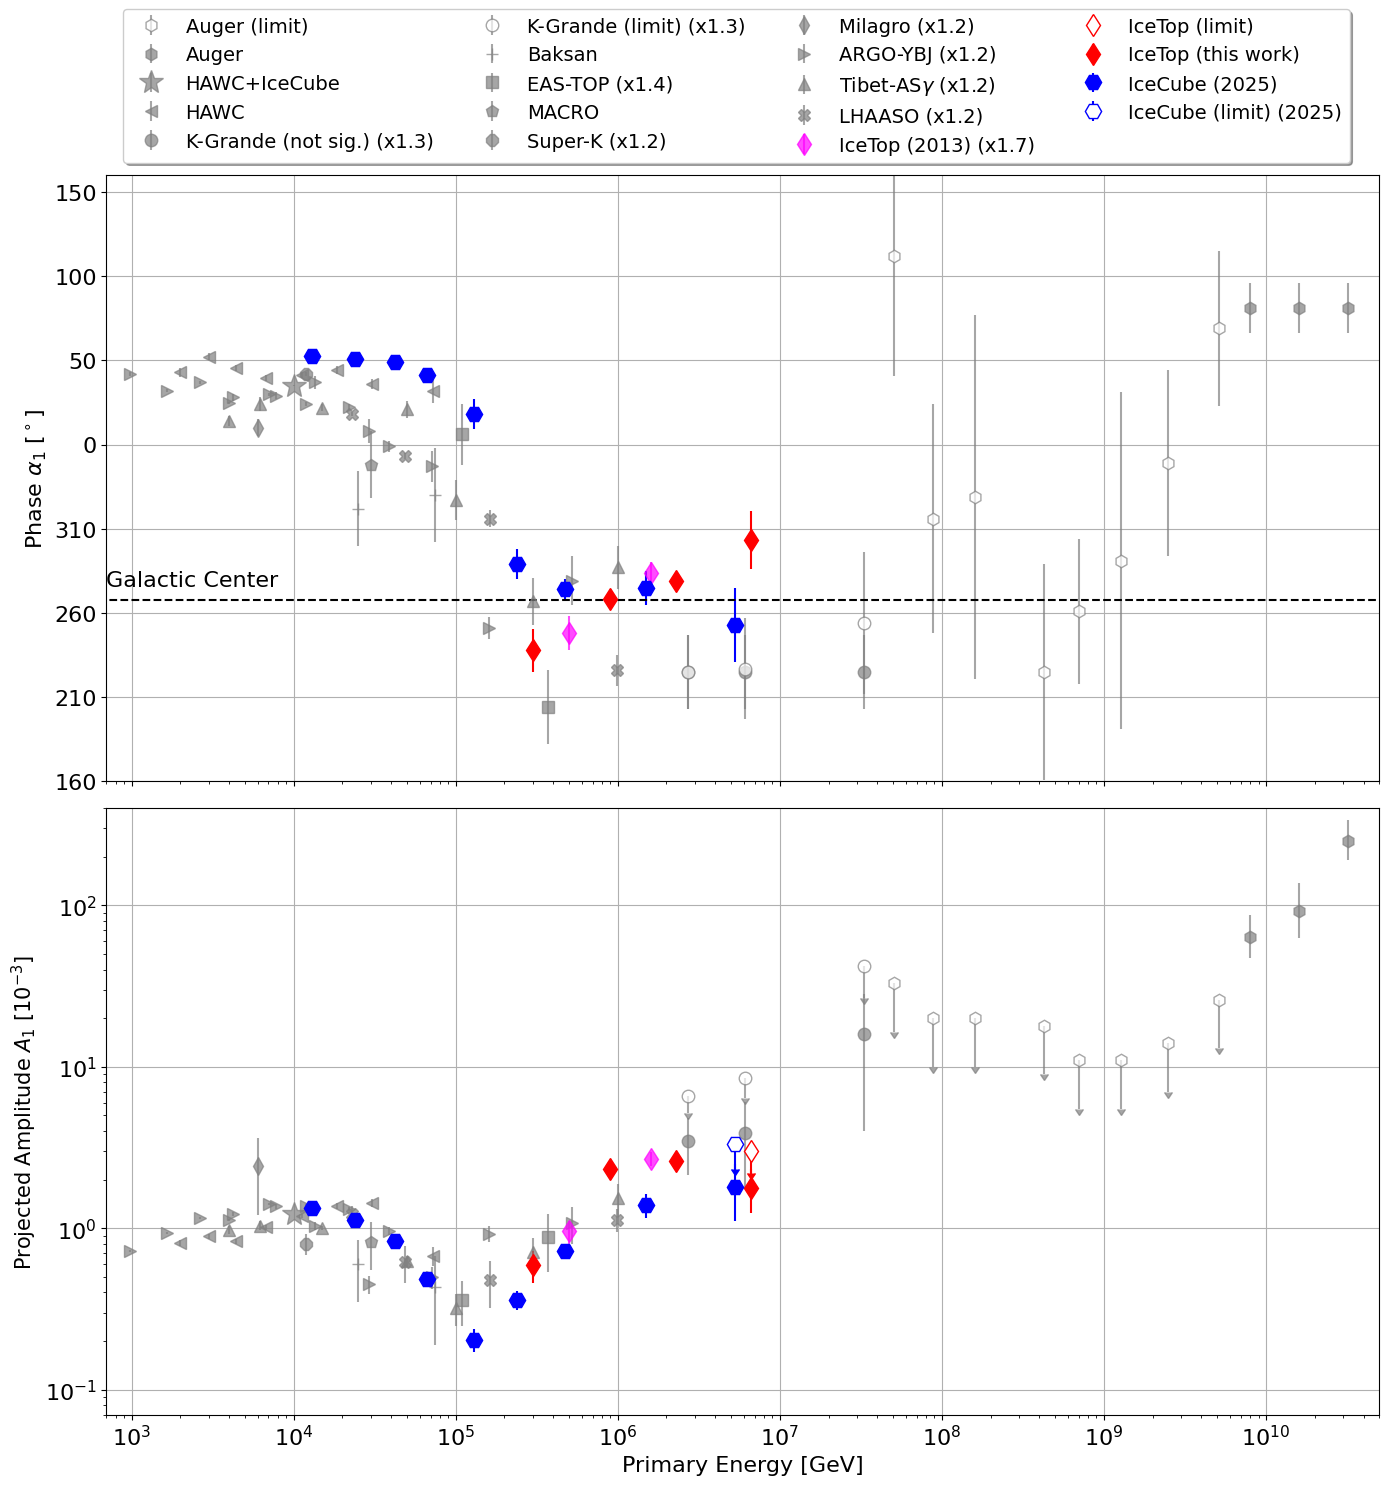

In [1]:
#!/usr/bin/env python
# coding: utf-8


import sys, os, os.path
import matplotlib
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from scipy import stats
import glob, argparse, os
import json
from matplotlib.ticker import FuncFormatter, MaxNLocator




class Point:
    def __init__(self, energy, A1=0, A1errHi=0,A1errLo=0,alpha=0,alpha_err=0,upperlim=0,lowerlim=0):
        self.energy = energy
        self.A1 = A1
        self.A1errHi = A1errHi
        self.A1errLo = A1errLo
        self.alpha = alpha
        self.alpha_err = alpha_err
        self.upperlim = upperlim
        self.lowerlim = lowerlim

class Experiment:
    def __init__(self, name, data=[], scale=1.0,color='black',shape='^', 
            markersize=1,facecolor=None,uplim=False, 
                 DOI=None,include=True, alpha=0.7,
                 hide=False
                ):

        self.name = name
        self.data = [Point(**d) for d in data]
        self.scale = scale
        self.color = color
        self.shape = shape
        self.markersize = markersize
        self.facecolor = color
        self.uplim = uplim
        self.DOI = DOI
        self.include = include
        self.alpha = alpha
        self.hide = hide
        if self.facecolor:
            self.facecolor=facecolor





    
    

def phase_amp_exp(exp_data, out,  fov=False):
    
    phase_data_points = {}
    with open(exp_data,"r") as datafile:
        phase_data_points = json.load(datafile)


    fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True,figsize=(14,15))
    fig.set_tight_layout(True)
    ax1 = axs[0]
    ax2 = axs[1]
    bins=np.logspace(1,8,10)
    xmin, xmax = 7e2,5e10

    for d in phase_data_points:
        detector = Experiment(**phase_data_points[d])
        if detector.hide:
            continue
        fov_correction = 1.0

        if fov: # Correct amplitude to account for FoV
            fov_correction = detector.scale
            if fov_correction != 1.0:
                detector.name = "{} (x{:0.1f})".format(detector.name,detector.scale)

        #if not detector.include: continue
        data = []
        print(detector.name)
        for datum in detector.data:
                alpha = datum.alpha
                if alpha > 180: alpha = alpha - 360
                data.append((
                    datum.energy*1e3,datum.A1,datum.A1errHi,datum.A1errLo,
                    datum.upperlim,datum.lowerlim,
                    alpha,datum.alpha_err))
        dE,A,dAhi,dAlo,uplims,lolims,alpha,dalpha = zip(*sorted(data))
        dE = np.array(dE)
        A = np.array(A)*1e-1*fov_correction
        dAhi = np.array(dAhi)*1e-1*fov_correction
        dAlo = np.array(dAlo)*1e-1*fov_correction
        alpha = np.array(alpha)
        dalpha = np.array(dalpha)
        lim_mask= np.array(uplims)

        ax1.errorbar(dE, alpha, yerr=dalpha, 
                fmt='*',marker=detector.shape,
                color=detector.color,mfc=detector.facecolor,label=detector.name,
                markersize=detector.markersize*9, alpha=detector.alpha)

        ax2.errorbar(dE,A,yerr=[dAlo,dAhi],fmt="*",marker=detector.shape, 
                color=detector.color,mfc=detector.facecolor,label=detector.name,uplims=uplims,
                markersize=detector.markersize*9, alpha=detector.alpha)


    GC = [[0,1e14],[267.8-360,267.8-360]]
    ax1.text(xmin, GC[1][0]+8, 'Galactic Center', ha= 'left', fontsize=16)
    ax1.plot(GC[0],GC[1],'--',color='black')  
    ax2.set_yscale('log')
    plt.xscale('log')


    # Shrink current axis by 20%
    box = ax1.get_position()

    ncol=5
    bbox_to_anchor=(0.495, 1.22)
    if fov: # Legends include scale and require more space
        ncol=4
        bbox_to_anchor=(0.495, 1.29)
    leg = ax1.legend(loc='upper center', bbox_to_anchor=bbox_to_anchor,
                            ncol=ncol, fancybox=True, shadow=True,
                            numpoints=1,fontsize=14)
    plt.xlabel("Primary Energy [GeV]",fontsize=16)
    ax1.set_ylabel(r'Phase $\alpha_1$ [$^\circ$]',fontsize=16)
    ax1.set_ylim(-200,160)
    ax2.set_ylabel("Projected Amplitude $A_1$ [$10^{-3}$]",fontsize=15)
    plt.xlim(xmin,xmax)
    ax2.set_ylim(7e-2,4e2)
    
    ax1.grid()
    ax2.grid()

    for item in (ax2.get_xticklabels() + ax2.get_yticklabels() + ax1.get_yticklabels()):
                item.set_fontsize(16)


    def format_fn(tick_val, tick_pos):
        if tick_val < 0: 
            return '%d' % (tick_val+360)
        else:
            return '%d' % tick_val

    def format_fnA(tick_val, tick_pos):
        return '%01.2f' % (tick_val)
     
        
    ax1.yaxis.set_major_formatter(FuncFormatter(format_fn))
    if out:
        fig.savefig(out, dpi=100, bbox_inches='tight')
    plt.show()
    
    
data_dir ='/data/user/juancarlos/git/wg-cosmic-rays/analyses/IC86.2011-IC86.2021_CRAnisotropy/data'
exp_data = f'{data_dir}/phase_amplitude_data_IT.json'
phase_amp_exp(exp_data, 'Dipole_and_phase_IT_exp.pdf',  fov=True)

In [2]:
sys.path.append('/data/user/juancarlos/git/wg-cosmic-rays/analyses/IC86.2011-IC86.2021_CRAnisotropy/dat')


Auger (limit)
Auger
HAWC+IceCube
HAWC
K-Grande (not sig.) (x1.3)
K-Grande (limit) (x1.3)
Baksan
EAS-TOP (x1.4)
MACRO
Super-K (x1.2)
Milagro (x1.2)
ARGO-YBJ (x1.2)
Tibet-AS$\gamma$ (x1.2)
LHAASO (x1.2)
IceTop (2013) (x1.7)
IceTop (limit)
IceTop (this work)
IceCube (2025)
IceCube (limit) (2025)


/tmp/ipykernel_9889/869472752.py:100: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "*" (-> marker='*'). The keyword argument will take precedence.
  ax1.errorbar(dE, alpha, yerr=dalpha,
/cvmfs/icecube.opensciencegrid.org/py3-v4.3.0/Ubuntu_22.04_x86_64/lib/python3.11/site-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


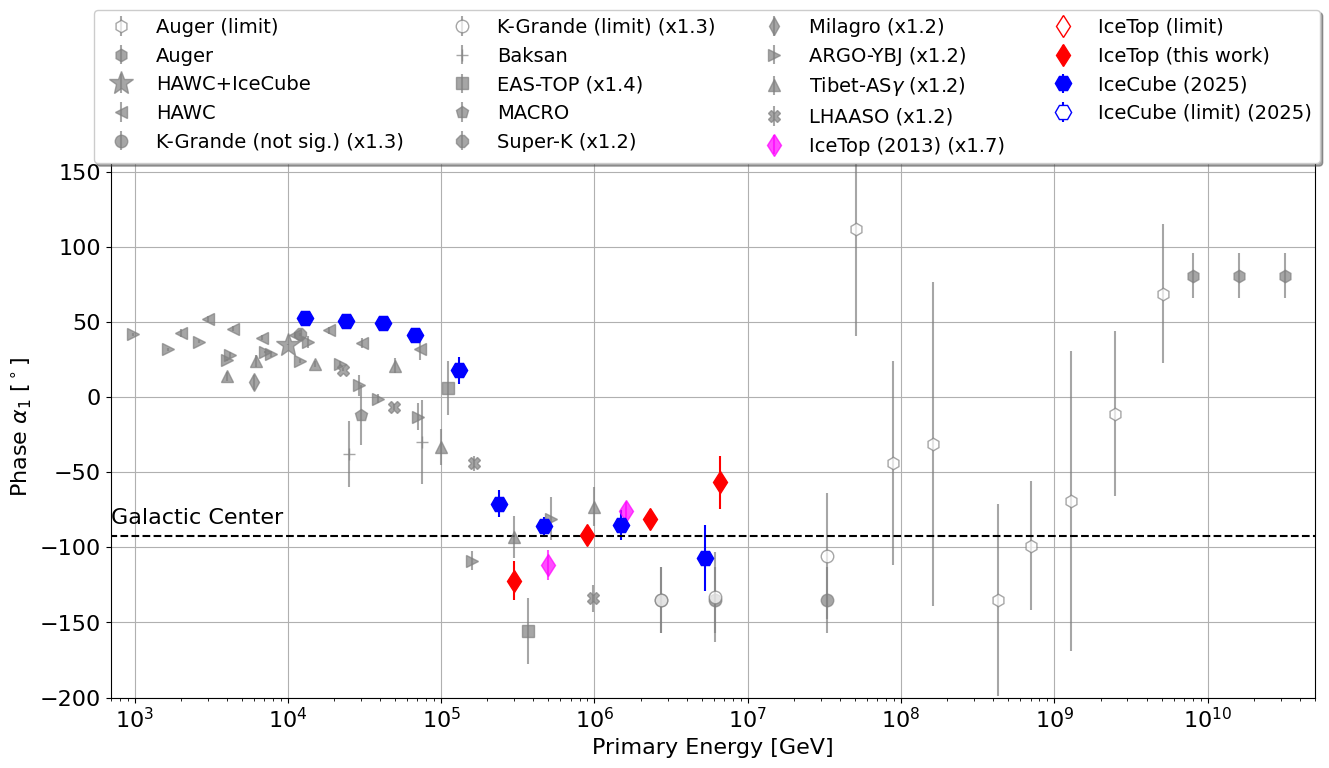

Auger (limit)
Auger
HAWC+IceCube
HAWC
K-Grande (not sig.) (x1.3)
K-Grande (limit) (x1.3)
Baksan
EAS-TOP (x1.4)
MACRO
Super-K (x1.2)
Milagro (x1.2)
ARGO-YBJ (x1.2)
Tibet-AS$\gamma$ (x1.2)
LHAASO (x1.2)
IceTop (2013) (x1.7)
IceTop (limit)
IceTop (this work)
IceCube (2025)
IceCube (limit) (2025)


/tmp/ipykernel_9889/869472752.py:167: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "*" (-> marker='*'). The keyword argument will take precedence.
  ax2.errorbar(dE,A,yerr=[dAlo,dAhi],fmt="*",marker=detector.shape,


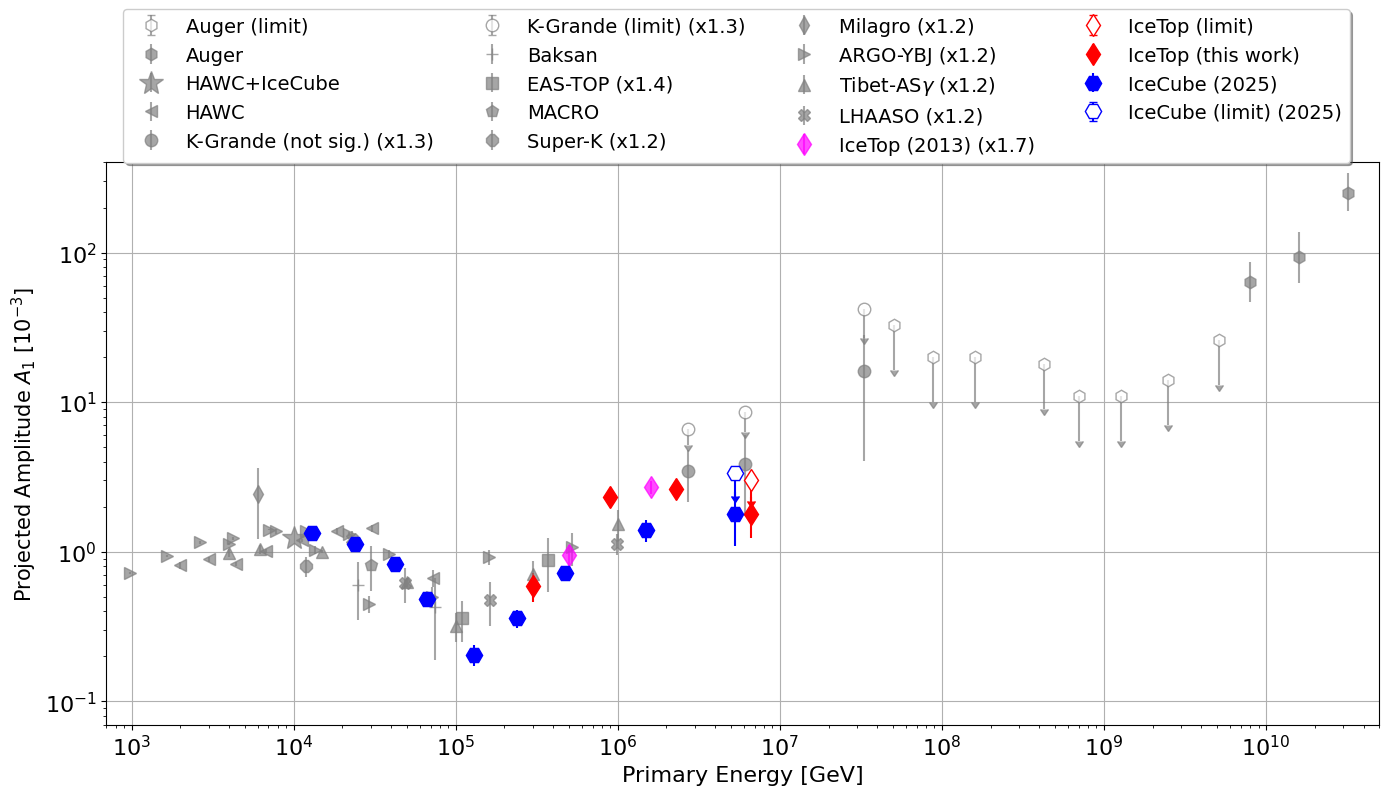

In [3]:
#!/usr/bin/env python
# coding: utf-8


import sys, os, os.path
import matplotlib
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from scipy import stats
import glob, argparse, os
import json
from matplotlib.ticker import FuncFormatter, MaxNLocator




class Point:
    def __init__(self, energy, A1=0, A1errHi=0,A1errLo=0,alpha=0,alpha_err=0,upperlim=0,lowerlim=0):
        self.energy = energy
        self.A1 = A1
        self.A1errHi = A1errHi
        self.A1errLo = A1errLo
        self.alpha = alpha
        self.alpha_err = alpha_err
        self.upperlim = upperlim
        self.lowerlim = lowerlim

class Experiment:
    def __init__(self, name, data=[], scale=1.0,color='black',shape='^', 
            markersize=1,facecolor=None,uplim=False, 
                 DOI=None,include=True, alpha=0.7,
                 hide=False
                ):

        self.name = name
        self.data = [Point(**d) for d in data]
        self.scale = scale
        self.color = color
        self.shape = shape
        self.markersize = markersize
        self.facecolor = color
        self.uplim = uplim
        self.DOI = DOI
        self.include = include
        self.alpha = alpha
        self.hide = hide
        if self.facecolor:
            self.facecolor=facecolor





    
    

def phase_amp_exp_split(exp_data, out,  fov=False):
    
    phase_data_points = {}
    with open(exp_data,"r") as datafile:
        phase_data_points = json.load(datafile)

    fig, ax1 =plt.subplots(figsize=(14,8))
    fig.set_tight_layout(True)

    bins=np.logspace(1,8,10)
    xmin, xmax = 7e2,5e10

    for d in phase_data_points:
        detector = Experiment(**phase_data_points[d])
        if detector.hide:
            continue
        fov_correction = 1.0

        if fov: # Correct amplitude to account for FoV
            fov_correction = detector.scale
            if fov_correction != 1.0:
                detector.name = "{} (x{:0.1f})".format(detector.name,detector.scale)

        #if not detector.include: continue
        data = []
        print(detector.name)
        for datum in detector.data:
                alpha = datum.alpha
                if alpha > 180: alpha = alpha - 360
                data.append((
                    datum.energy*1e3,datum.A1,datum.A1errHi,datum.A1errLo,
                    datum.upperlim,datum.lowerlim,
                    alpha,datum.alpha_err))
        dE,A,dAhi,dAlo,uplims,lolims,alpha,dalpha = zip(*sorted(data))
        dE = np.array(dE)
        A = np.array(A)*1e-1*fov_correction
        dAhi = np.array(dAhi)*1e-1*fov_correction
        dAlo = np.array(dAlo)*1e-1*fov_correction
        alpha = np.array(alpha)
        dalpha = np.array(dalpha)
        lim_mask= np.array(uplims)

        ax1.errorbar(dE, alpha, yerr=dalpha, 
                fmt='*',marker=detector.shape,
                color=detector.color,mfc=detector.facecolor,label=detector.name,
                markersize=detector.markersize*9, alpha=detector.alpha)


    GC = [[0,1e14],[267.8-360,267.8-360]]
    ax1.text(xmin, GC[1][0]+8, 'Galactic Center', ha= 'left', fontsize=16)
    ax1.plot(GC[0],GC[1],'--',color='black')  
    
    

    # Shrink current axis by 20%
    box = ax1.get_position()

    ncol=5
    bbox_to_anchor=(0.495, 1.22)
    if fov: # Legends include scale and require more space
        ncol=4
        bbox_to_anchor=(0.495, 1.29)
    leg = ax1.legend(loc='upper center', bbox_to_anchor=bbox_to_anchor,
                            ncol=ncol, fancybox=True, shadow=True,
                            numpoints=1,fontsize=14)
    plt.xlabel("Primary Energy [GeV]",fontsize=16)
    ax1.set_ylabel(r'Phase $\alpha_1$ [$^\circ$]',fontsize=16)
    ax1.set_ylim(-200,160)
    plt.xscale('log')
    plt.xlim(xmin,xmax)
    for item in (ax1.get_xticklabels()  + ax1.get_yticklabels()):
                item.set_fontsize(16)
    
    ax1.grid()
    plt.show()
    
    fig, ax2 = plt.subplots(figsize=(14,8))
    fig.set_tight_layout(True)
    for d in phase_data_points:
        detector = Experiment(**phase_data_points[d])
        if detector.hide:
            continue
        fov_correction = 1.0

        if fov: # Correct amplitude to account for FoV
            fov_correction = detector.scale
            if fov_correction != 1.0:
                detector.name = "{} (x{:0.1f})".format(detector.name,detector.scale)

        #if not detector.include: continue
        data = []
        print(detector.name)
        for datum in detector.data:
                alpha = datum.alpha
                if alpha > 180: alpha = alpha - 360
                data.append((
                    datum.energy*1e3,datum.A1,datum.A1errHi,datum.A1errLo,
                    datum.upperlim,datum.lowerlim,
                    alpha,datum.alpha_err))
        dE,A,dAhi,dAlo,uplims,lolims,alpha,dalpha = zip(*sorted(data))
        dE = np.array(dE)
        A = np.array(A)*1e-1*fov_correction
        dAhi = np.array(dAhi)*1e-1*fov_correction
        dAlo = np.array(dAlo)*1e-1*fov_correction
        alpha = np.array(alpha)
        dalpha = np.array(dalpha)
        lim_mask= np.array(uplims)


        ax2.errorbar(dE,A,yerr=[dAlo,dAhi],fmt="*",marker=detector.shape, 
                color=detector.color,mfc=detector.facecolor,label=detector.name,uplims=uplims,
                markersize=detector.markersize*9, alpha=detector.alpha)




    # Shrink current axis by 20%
    box = ax2.get_position()

    ncol=5
    bbox_to_anchor=(0.495, 1.22)
    if fov: # Legends include scale and require more space
        ncol=4
        bbox_to_anchor=(0.495, 1.29)
    leg = ax2.legend(loc='upper center', bbox_to_anchor=bbox_to_anchor,
                            ncol=ncol, fancybox=True, shadow=True,
                            numpoints=1,fontsize=14)
    
    plt.xlabel("Primary Energy [GeV]",fontsize=16)
    ax2.set_yscale('log')
    ax2.set_ylabel("Projected Amplitude $A_1$ [$10^{-3}$]",fontsize=15)
    ax2.set_ylim(7e-2,4e2)
    plt.xlim(xmin,xmax)
    plt.xscale('log')
    ax2.grid()

    for item in (ax2.get_xticklabels() + ax2.get_yticklabels() ):
                item.set_fontsize(16)


    def format_fn(tick_val, tick_pos):
        if tick_val < 0: 
            return '%d' % (tick_val+360)
        else:
            return '%d' % tick_val

    def format_fnA(tick_val, tick_pos):
        return '%01.2f' % (tick_val)
     
        
    ax1.yaxis.set_major_formatter(FuncFormatter(format_fn))
    if out:
        fig.savefig(out, dpi=100, bbox_inches='tight')
    plt.show()
    
    
data_dir ='/data/user/juancarlos/git/wg-cosmic-rays/analyses/IC86.2011-IC86.2021_CRAnisotropy/data'
exp_data = f'{data_dir}/phase_amplitude_data_IT.json'

phase_amp_exp_split(exp_data, 'Dipole_and_phase_IT_exp.pdf',  fov=True)